# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# Your comment here

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [6]:
g = 9.81 #meters/s^2
L = 1.0 #meters

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [9]:
def pendulum(t, y):
    theta, omega = y #y[0] = theta, y[1] = omega
    dtheta_dt = omega
    domega_dt = - (g / L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [62]:
theta_0 = np.radians(10) # Convert 10 degrees to radians (max displacement)
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [15]:
t_span = (0, 10) #10-sec simulation
t_eval = np.linspace(0, 10, 500) #time steps for evaluation
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval = t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [18]:
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [64]:
def small_angle_period(theta_0, L, time_values):
    #Approximates the period and theta values using small angle approximation (cosine solution)
    T_approx = 2 * np.pi * np.sqrt(L / g)
    SHM_cosine = theta_0 * np.cos(2 * np.pi * time_values / T_approx) #use cosine because pendulum starts displaced
    return SHM_cosine, T_approx 

theta_values_approx, T_approx = small_angle_period(theta_0, 1, time_values)

theta_values_approx
T_approx

2.0060666807106475

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [58]:
print(f"Theoretical period (small-angle approximation): {T_approx: .2f} seconds")

Theoretical period (small-angle approximation):  2.01 seconds


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [20]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

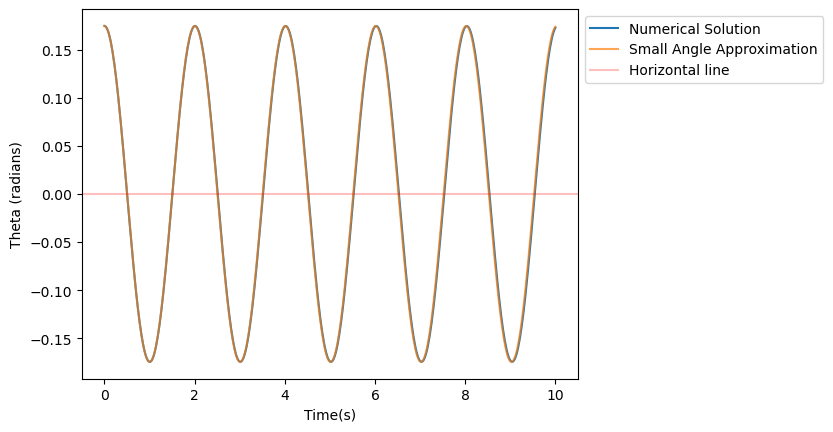

In [94]:
plt.plot(time_values, theta_values, label = "Numerical Solution")
plt.plot(time_values, theta_values_approx, label = "Small Angle Approximation", alpha = 0.7 )
plt.axhline(0, color = "red", label = "Horizontal line", alpha = 0.25)
plt.xlabel("Time(s)")
plt.ylabel("Theta (radians)")
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [112]:
print(f"Numerical period: {T_numerical: .4f}")

Numerical period:  2.0040


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [118]:
#Numerical Calculation
print(theta_values)
print(len(theta_values))

#Small-Angle Approximation
print(theta_values_approx)
print(len(theta_values_approx))

differences = [value for value in theta_values if value not in theta_values_approx]
print(differences)
print(len(differences))

#Numerical Period: 2.0040, Theoretical Period: ~2.006

#Despite the "differences" list showing that the two calculations are only about a 0.9% match, the graphs show that the two calculations match well (up to perhaps some thousandth decimal differences)

[ 0.17453293  0.17419097  0.17316644  0.17146329  0.16908857  0.1660522
  0.16236546  0.15804208  0.15309833  0.14755293  0.14142714  0.13474472
  0.12753192  0.11981748  0.11163268  0.10301127  0.09398569  0.08459012
  0.07486253  0.06484153  0.05456631  0.0440767   0.03341314  0.02261669
  0.01172902  0.00079243 -0.01015019 -0.0210553  -0.03187877 -0.04257585
 -0.05310115 -0.06341295 -0.0734805  -0.08326177 -0.09271571 -0.10180347
 -0.11048841 -0.1187361  -0.1265143  -0.133793   -0.14054437 -0.14674282
 -0.15236494 -0.15738954 -0.16179763 -0.16557244 -0.16870008 -0.17117338
 -0.17298104 -0.17411315 -0.17456291 -0.17432659 -0.17340361 -0.17179645
 -0.16951071 -0.1665551  -0.16294141 -0.15868454 -0.1538025  -0.14831638
 -0.14225041 -0.13563188 -0.12848933 -0.12084395 -0.11272487 -0.10416392
 -0.09519426 -0.08585033 -0.07616794 -0.06618416 -0.0559374  -0.04546738
 -0.03481513 -0.024023   -0.01313464 -0.00219502  0.00874956  0.01965375
  0.03048471  0.04119878  0.05175108  0.06209835  0.

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [120]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [122]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [146]:
coviddata = pd.read_csv("coviddata.csv")
coviddata

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN


Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [161]:
df_country = coviddata[coviddata["location"].str.contains("United States")]
df_country

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
403451,USA,North America,United States,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,-1914.9,-3.09,-3.09,-5.700091
403452,USA,North America,United States,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403453,USA,North America,United States,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403454,USA,North America,United States,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403455,USA,North America,United States,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406794,VIR,North America,United States Virgin Islands,2024-07-31,25389.0,0.0,0.0,132.0,0.0,0.0,...,NaN,NaN,NaN,80.58,NaN,99479,NaN,NaN,NaN,NaN
406795,VIR,North America,United States Virgin Islands,2024-08-01,25389.0,0.0,0.0,132.0,0.0,0.0,...,NaN,NaN,NaN,80.58,NaN,99479,NaN,NaN,NaN,NaN
406796,VIR,North America,United States Virgin Islands,2024-08-02,25389.0,0.0,0.0,132.0,0.0,0.0,...,NaN,NaN,NaN,80.58,NaN,99479,NaN,NaN,NaN,NaN
406797,VIR,North America,United States Virgin Islands,2024-08-03,25389.0,0.0,0.0,132.0,0.0,0.0,...,NaN,NaN,NaN,80.58,NaN,99479,NaN,NaN,NaN,NaN


From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [171]:
df_country.dropna(axis = 1)
df_country = df_country[["iso_code", "continent", "location", "date", "total_cases"]]
df_country

,iso_code,continent,location,date,total_cases
403451,USA,North America,United States,2020-01-05,0.0
403452,USA,North America,United States,2020-01-06,0.0
403453,USA,North America,United States,2020-01-07,0.0
403454,USA,North America,United States,2020-01-08,0.0
403455,USA,North America,United States,2020-01-09,0.0
...,...,...,...,...,...
406794,VIR,North America,United States Virgin Islands,2024-07-31,25389.0
406795,VIR,North America,United States Virgin Islands,2024-08-01,25389.0
406796,VIR,North America,United States Virgin Islands,2024-08-02,25389.0
406797,VIR,North America,United States Virgin Islands,2024-08-03,25389.0


In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [235]:
reference_date = df_country["date"].min()
reference_date

ref_date_time = pd.to_datetime(reference_date)

In [237]:
range(len(df_country))
datetime_times = pd.to_datetime(df_country["date"])
datetime_time = (datetime_times - ref_date_time).dt.days
datetime_time

403451       0
403452       1
403453       2
403454       3
403455       4
          ... 
406794    1669
406795    1670
406796    1671
406797    1672
406798    1673
Name: date, Length: 3348, dtype: int64

In [231]:
df_country.insert(4, "Days Since Start", datetime_time)

In [239]:
df_country

,iso_code,continent,location,date,Days Since Start,total_cases
403451,USA,North America,United States,2020-01-05,0,0.0
403452,USA,North America,United States,2020-01-06,1,0.0
403453,USA,North America,United States,2020-01-07,2,0.0
403454,USA,North America,United States,2020-01-08,3,0.0
403455,USA,North America,United States,2020-01-09,4,0.0
...,...,...,...,...,...,...
406794,VIR,North America,United States Virgin Islands,2024-07-31,1669,25389.0
406795,VIR,North America,United States Virgin Islands,2024-08-01,1670,25389.0
406796,VIR,North America,United States Virgin Islands,2024-08-02,1671,25389.0
406797,VIR,North America,United States Virgin Islands,2024-08-03,1672,25389.0


Print the first few rows of your `df_country` dataframe.

In [243]:
print(df_country.head(3))

       iso_code      continent       location        date  Days Since Start  \
403451      USA  North America  United States  2020-01-05                 0   
403452      USA  North America  United States  2020-01-06                 1   
403453      USA  North America  United States  2020-01-07                 2   

        total_cases  
403451          0.0  
403452          0.0  
403453          0.0  


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [245]:
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [247]:
def exponential_growth(t, C_0, r):
    number_cases = C_0 * np.exp(r * t)
    return number_cases

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [263]:
days = (df_country["Days Since Start"][:30])

cases = (df_country["total_cases"][:30])

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [265]:
popt, pcov = curve_fit(exponential_growth, days, cases)

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [268]:
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [272]:
print(f"Initial Value: {C0_fit: .4f}")
print(f"Growth Rate: {r_fit: .4f}")

Initial Value:  0.1239
Growth Rate:  0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [276]:
future_days = np.arange(0, 61, 1)
future_days

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60])

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [280]:
predicted_cases = exponential_growth(future_days, C0_fit, r_fit)
predicted_cases

array([1.23895215e-01, 1.44499878e-01, 1.68531245e-01, 1.96559201e-01,
       2.29248408e-01, 2.67374063e-01, 3.11840289e-01, 3.63701568e-01,
       4.24187750e-01, 4.94733218e-01, 5.77010903e-01, 6.72971958e-01,
       7.84892026e-01, 9.15425204e-01, 1.06766699e+00, 1.24522767e+00,
       1.45231797e+00, 1.69384888e+00, 1.97554810e+00, 2.30409593e+00,
       2.68728363e+00, 3.13419818e+00, 3.65543784e+00, 4.26336339e+00,
       4.97239133e+00, 5.79933570e+00, 6.76380686e+00, 7.88867649e+00,
       9.20062002e+00, 1.07307492e+01, 1.25153498e+01, 1.45967423e+01,
       1.70242853e+01, 1.98555462e+01, 2.31576661e+01, 2.70089522e+01,
       3.15007348e+01, 3.67395331e+01, 4.28495812e+01, 4.99757742e+01,
       5.82871041e+01, 6.79806680e+01, 7.92863411e+01, 9.24722287e+01,
       1.07851024e+02, 1.25787424e+02, 1.46706775e+02, 1.71105165e+02,
       1.99561182e+02, 2.32749639e+02, 2.71457575e+02, 3.16602919e+02,
       3.69256257e+02, 4.30666223e+02, 5.02289107e+02, 5.85823391e+02,
      

In [282]:
predicted_cases2 = exponential_growth(future_days, *popt)
predicted_cases2

array([1.23895215e-01, 1.44499878e-01, 1.68531245e-01, 1.96559201e-01,
       2.29248408e-01, 2.67374063e-01, 3.11840289e-01, 3.63701568e-01,
       4.24187750e-01, 4.94733218e-01, 5.77010903e-01, 6.72971958e-01,
       7.84892026e-01, 9.15425204e-01, 1.06766699e+00, 1.24522767e+00,
       1.45231797e+00, 1.69384888e+00, 1.97554810e+00, 2.30409593e+00,
       2.68728363e+00, 3.13419818e+00, 3.65543784e+00, 4.26336339e+00,
       4.97239133e+00, 5.79933570e+00, 6.76380686e+00, 7.88867649e+00,
       9.20062002e+00, 1.07307492e+01, 1.25153498e+01, 1.45967423e+01,
       1.70242853e+01, 1.98555462e+01, 2.31576661e+01, 2.70089522e+01,
       3.15007348e+01, 3.67395331e+01, 4.28495812e+01, 4.99757742e+01,
       5.82871041e+01, 6.79806680e+01, 7.92863411e+01, 9.24722287e+01,
       1.07851024e+02, 1.25787424e+02, 1.46706775e+02, 1.71105165e+02,
       1.99561182e+02, 2.32749639e+02, 2.71457575e+02, 3.16602919e+02,
       3.69256257e+02, 4.30666223e+02, 5.02289107e+02, 5.85823391e+02,
      

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

Text(0.5, 1.0, 'Prediction of COVID-19 Cases (Exponential Curvefit)')

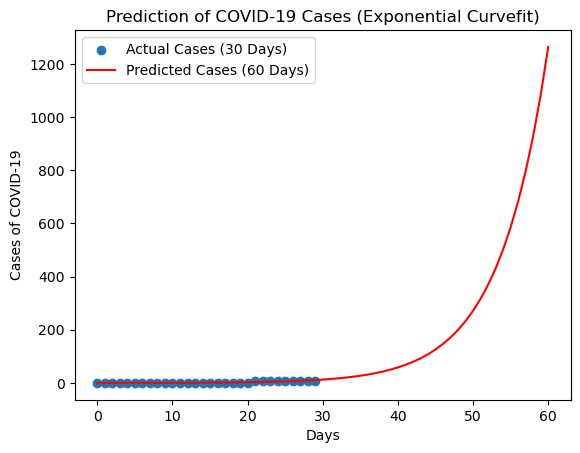

In [302]:
plt.scatter(days, cases, label = "Actual Cases (30 Days)")
plt.plot(future_days, predicted_cases, color = "red", label = "Predicted Cases (60 Days)")
plt.xlabel("Days")
plt.ylabel("Cases of COVID-19")
plt.legend()
plt.title("Prediction of COVID-19 Cases (Exponential Curvefit)")

How well does your exponential model fit the actual COVID-19 data? 

In [308]:
#I think it fits pretty well; it's hard to tell given the actual data only spans 30 days, but the scatterplot points seem to be increasing like an exponential function at first.

Make another plot but this time to **90 days**.

Text(0.5, 1.0, 'Prediction of COVID-19 Cases (Exponential Curvefit)')

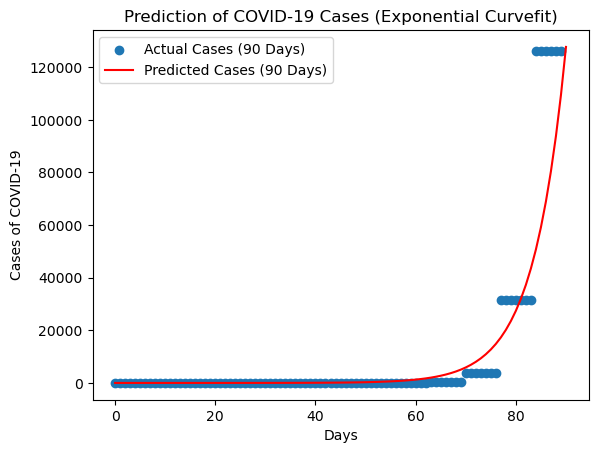

In [312]:
future_days2 = np.arange(0, 91, 1)

days2 = (df_country["Days Since Start"][:90])

cases2 = (df_country["total_cases"][:90])

predicted_cases3 = exponential_growth(future_days2, *popt)

plt.scatter(days2, cases2, label = "Actual Cases (90 Days)")
plt.plot(future_days2, predicted_cases3, color = "red", label = "Predicted Cases (90 Days)")
plt.xlabel("Days")
plt.ylabel("Cases of COVID-19")
plt.legend()
plt.title("Prediction of COVID-19 Cases (Exponential Curvefit)")

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [318]:
print(f"Predicted Cases at 87 Days: {predicted_cases3[87]: .2f}")

Predicted Cases at 87 Days:  80497.25


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [320]:
import seaborn as sns

In [330]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


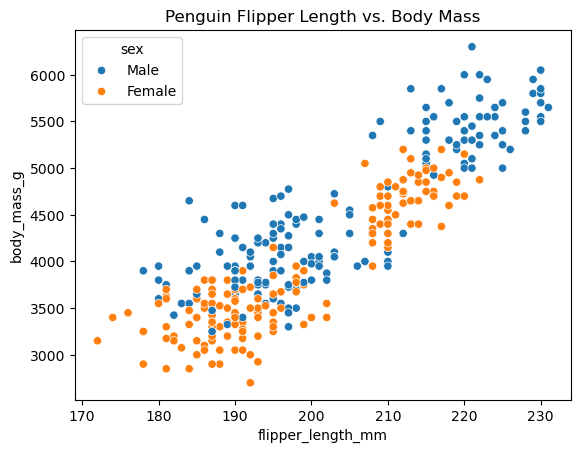

In [338]:
sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", hue = "sex")
plt.title("Penguin Flipper Length vs. Body Mass")
plt.show()

In [340]:
from scipy.stats import linregress

Correlation Coefficient:  0.87
Probability Value:  0.00
Standard Error:  1.52


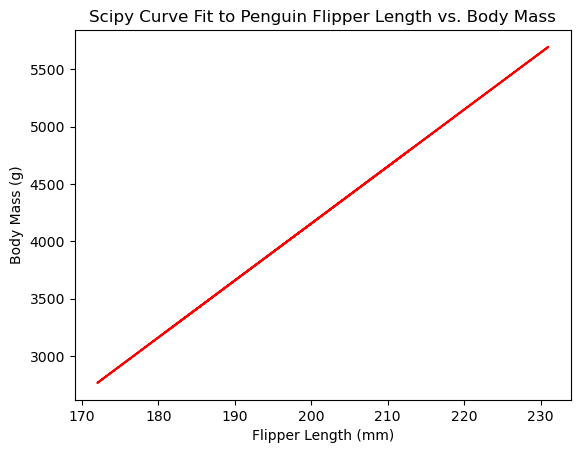

In [366]:
x = penguins["flipper_length_mm"].dropna()
y = penguins["body_mass_g"].dropna()

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Correlation Coefficient: {r_value: .2f}")
print(f"Probability Value: {p_value: .2f}")
print(f"Standard Error: {std_err: .2f}")

plt.plot(x, slope * x + intercept, color = "red", label = "Scipy Model")
plt.title("Scipy Curve Fit to Penguin Flipper Length vs. Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

On it's own branch, submit this notebook to Gradescope! 

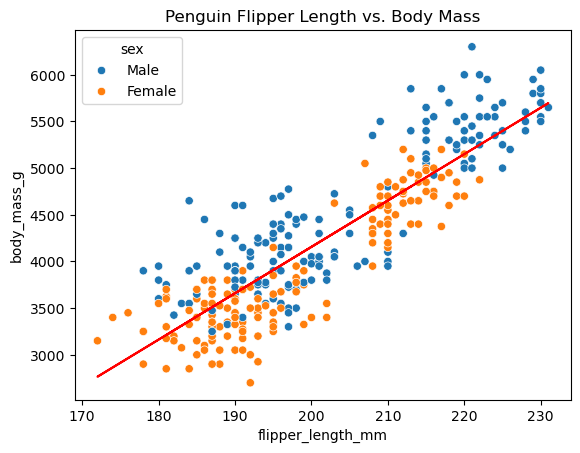

In [372]:
sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", hue = "sex")
plt.plot(x, slope * x + intercept, color = "red", label = "Scipy Model")

plt.title("Penguin Flipper Length vs. Body Mass")

plt.show()